In [ ]:
# dataset link
#https://www.kaggle.com/datasets/pranavraikokte/covid19-image-dataset

In [ ]:

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.models import Sequential # is used create the cnn model layee by layer
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout
# conv is used to detect the edges max pooling is used to reduce image size
# faltten convert 2d in to 1d
# dense prevent overfitting
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import confusion_matrix, classification_report

In [ ]:
DATA_PATH = "/content/drive/MyDrive/Covid19-dataset (1)"
train_dir = os.path.join(DATA_PATH, "train (1)")
test_dir  = os.path.join(DATA_PATH, "test (1)")
# checking
# to confrim path is correct
# dataset loaded properly

print("Train exists?", os.path.exists(train_dir))
print("Test exists?", os.path.exists(test_dir))
# tell number of classes
# model output should have 3 neuron
print("Train classes:", os.listdir(train_dir))

Train exists? True
Test exists? True
Train classes: ['Covid (1)', 'Viral Pneumonia (1)', 'Normal (1)']


In [ ]:
#  Fix Randomness in weight initialization,data shuffling
import random
tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

In [ ]:
# STEP 1: Imports
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import random


In [ ]:
train_ds = image_dataset_from_directory(
    train_dir,
    validation_split=0.2, # breaking the data in to 80 20 ratio
    subset="training",   # tell the tensor to take only training
    seed=42,
    image_size=(64,64),  # all images resized to 64, 64 becauses cnn
    #same size input and smaller size faster training
    batch_size=32,  # instead of training on the whole dataset 32 images at once
    shuffle=True   # mixes images
)
# checcking the data during the training phase
   # to detect the overfitting
val_ds = image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(64,64),
    batch_size=32,
    shuffle=False  # prediction must align with labels , inputs
)

Found 251 files belonging to 3 classes.
Using 201 files for training.
Found 251 files belonging to 3 classes.
Using 50 files for validation.


In [ ]:
# STEP 4: Create TEST dataset from TEST folder
test_ds = image_dataset_from_directory(
    test_dir,
    image_size=(64,64),
    batch_size=32,
    shuffle=False
)

Found 66 files belonging to 3 classes.


In [ ]:
# STEP 5: Get class names

class_names = train_ds.class_names # detect the folder in it
n_classes = len(class_names)  # count the classes
print("Class Names:", class_names)
print("Number of Classes:", n_classes)

Class Names: ['Covid (1)', 'Normal (1)', 'Viral Pneumonia (1)']
Number of Classes: 3


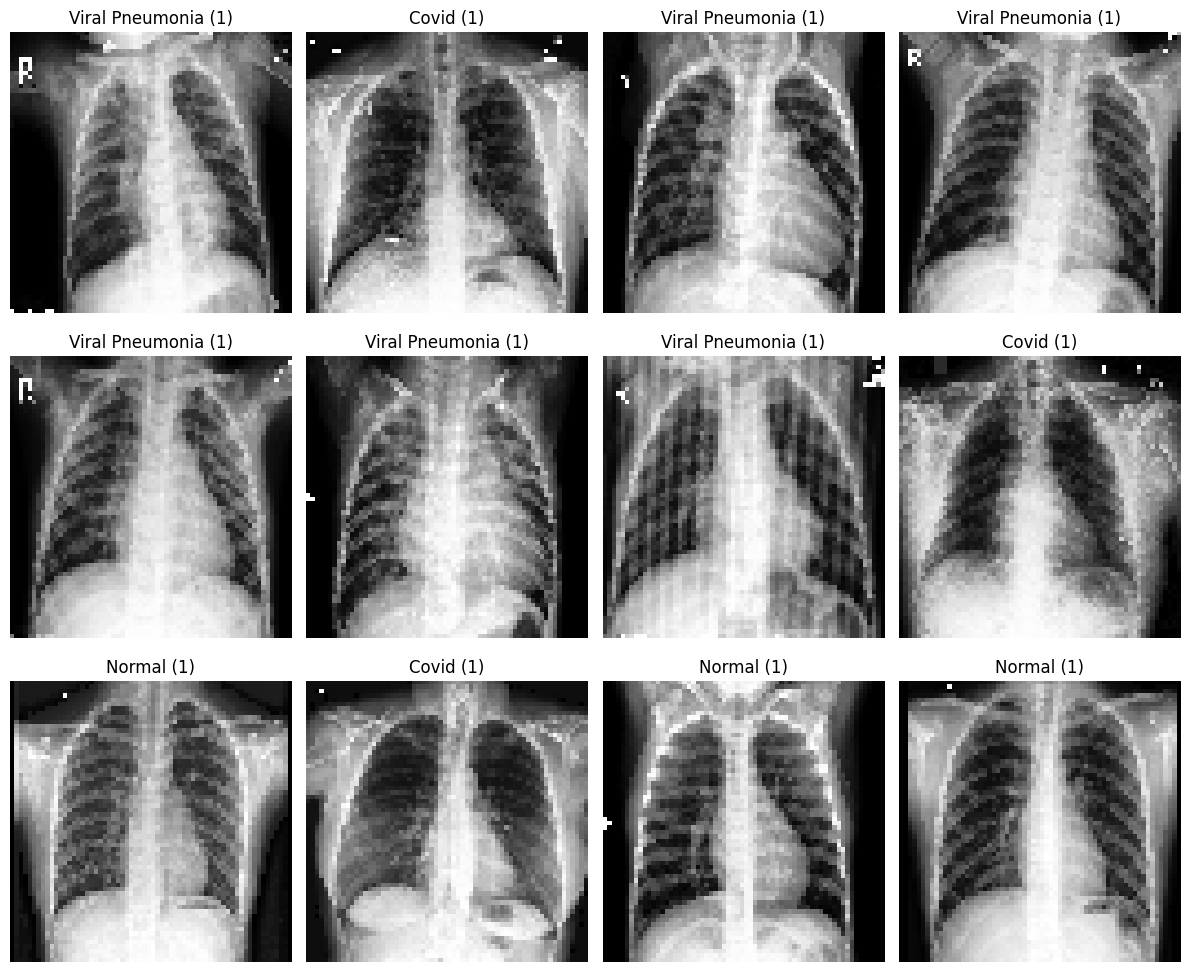

In [ ]:
# STEP 6: Show some images

plt.figure(figsize=(12,10))
for images, labels in train_ds.take(1):  # this mean take one batch of training data
    for i in range(12):
        plt.subplot(3,4,i+1)  #make grid of 3 rows and 4 columns
        plt.imshow(images[i].numpy().astype("uint8"))  # tensor to convert in normal image
                                           # then convert in color format
        plt.title(class_names[labels[i]])  # to show the label
        plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
# STEP 7: Rescale (0-1)
#converting the pixel value 0 (black)to 255(white) in to 0,1
def rescale(img, label):
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

train_ds = train_ds.map(rescale)  #used map to apply the function on every batch images
val_ds   = val_ds.map(rescale)
test_ds  = test_ds.map(rescale)
# make the training stable
# faster convergence

In [ ]:
# STEP 8: Prefetch (speed)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)  # GPU process one batch then next batch load in background
val_ds   = val_ds.prefetch(AUTOTUNE)
test_ds  = test_ds.prefetch(AUTOTUNE)

# here autotune i have used to tensor flow decide by its how much batch have to ready

In [ ]:
# data augnmentation
# make the new images
# make the  new images if the dataset is small prevent from over fitting
# make the model general
augment_layer = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.2),
])

In [ ]:
model = Sequential([
    Input(shape=(64,64,3)), # the model will take 64*64 images in color

# used the 32 filter use having 3*3 filter size Features detect karega (edges, patterns)

    Conv2D(32,(3,3),activation="relu"),# relu make the negative value zero to make training fast
    MaxPooling2D(2,2),
    #MaxPooling

#Image size half kar deta hai

#Important features rakhta ha


    Conv2D(64,(3,3),activation="relu"),# take 64 filter to complex feature Texture,Shape,Infection patterns
    MaxPooling2D(2,2),

    Conv2D(128,(3,3),activation="relu"),
    MaxPooling2D(2,2),  #128 filters  #High-level features detect karega  #Pneumonia patterns,COVID lung damage

    Flatten(),  #convert 2d to 1d
    Dense(128,activation="relu"),
    Dropout(0.5),  # 50% neuron randomly cloze during training due to over fitting

    Dense(n_classes,activation="softmax")  #Features ko combine karta hai
])      # softmax give in probabailty

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0007),
    # adam make the model learn how to update the weight
    loss="sparse_categorical_crossentropy",  # label number ma hu
    metrics=["accuracy"]
)

In [ ]:
early_stop = EarlyStopping(
    monitor="val_loss",  # Validation loss check
    patience=5,  # if there is no improvenment after the 5 epoches so stop training
    restore_best_weights=True  # put the best weight
)

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stop]
)
#Train dataset se seekho

#Validation se check karo

#Maximum 20 epochs

#Early stopping active

#Accuracy  how much predict correct from training images
# loss  this traing error how much the model is wrong
# validation accuracy model predict correct from un seen images
# validation loss make model generalize

Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.3776 - loss: 1.0894 - val_accuracy: 0.0000e+00 - val_loss: 1.0519
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 605ms/step - accuracy: 0.5505 - loss: 1.0229 - val_accuracy: 0.0000e+00 - val_loss: 1.1100
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 585ms/step - accuracy: 0.6014 - loss: 0.8896 - val_accuracy: 0.9200 - val_loss: 0.7033
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 945ms/step - accuracy: 0.7208 - loss: 0.6626 - val_accuracy: 0.8800 - val_loss: 0.5414
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 599ms/step - accuracy: 0.7934 - loss: 0.4862 - val_accuracy: 0.8400 - val_loss: 0.5260
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 628ms/step - accuracy: 0.7744 - loss: 0.4754 - val_accuracy: 0.9000 - val_loss: 0.3529
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 884ms/step - accuracy: 0.8594 - loss: 0.3613 - val_accuracy: 0.9000 - val_loss: 0.2727
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 625ms/step - accuracy: 0.9047 - loss: 0.2885 - val_accuracy: 0.9400 - val_

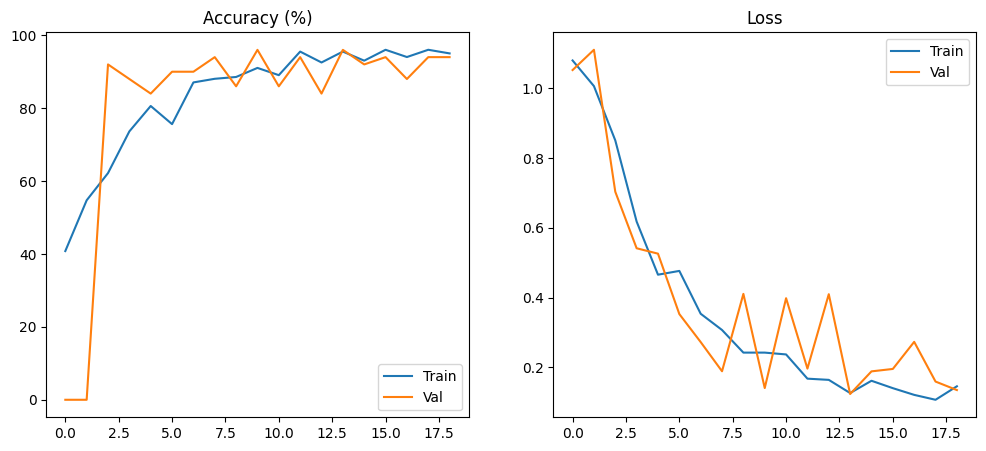

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot([x*100 for x in history.history['accuracy']], label='Train')
plt.plot([x*100 for x in history.history['val_accuracy']], label='Val')
plt.title("Accuracy (%)")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title("Loss")
plt.legend()

plt.show()
#Blue line = Training accuracy

# Orange line = Validation accuracy

#X-axis = Epochs (training rounds)

#Y-axis = Accuracy percentage


# at start loss is high after that it decreases

In [ ]:
test_loss, test_acc = model.evaluate(test_ds)
print("Final Test Accuracy: {:.2f}%".format(test_acc*100))

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 146ms/step - accuracy: 0.8232 - loss: 0.2410
Final Test Accuracy: 81.82%


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step


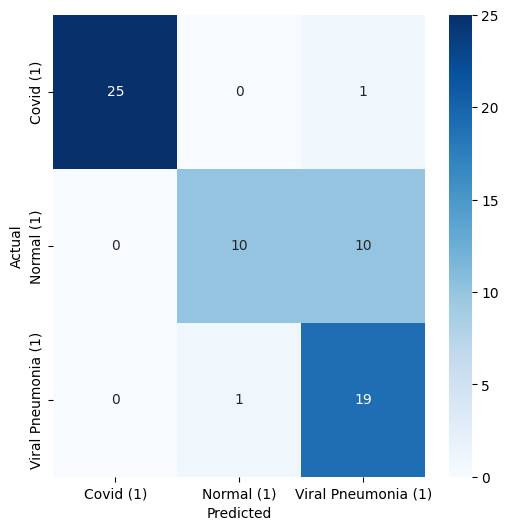

                     precision    recall  f1-score   support

          Covid (1)       1.00      0.96      0.98        26
         Normal (1)       0.91      0.50      0.65        20
Viral Pneumonia (1)       0.63      0.95      0.76        20

           accuracy                           0.82        66
          macro avg       0.85      0.80      0.80        66
       weighted avg       0.86      0.82      0.81        66



In [ ]:
y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names,
            cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(classification_report(y_true, y_pred, target_names=class_names))

#26 images total
#25 correct
#1 wrong

# normal
#20 images total
#10 sahi
#10 galat

#20 images total
#19 sahi
#1 galat

In [ ]:
model_lenet = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(64,64,3)), # Input now matches the dataset's image size

    tf.keras.layers.Conv2D(6, (5,5), activation='relu'),
    tf.keras.layers.AveragePooling2D(pool_size=(2,2)),

    tf.keras.layers.Conv2D(16, (5,5), activation='relu'),
    tf.keras.layers.AveragePooling2D(pool_size=(2,2)),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(120, activation='relu'),
    tf.keras.layers.Dense(84, activation='relu'),

    tf.keras.layers.Dense(n_classes, activation='softmax')
])

model_lenet.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_11 (Conv2D)              │ (None, 60, 60, 6)      │           456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_2             │ (None, 30, 30, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 26, 26, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_3             │ (None, 13, 13, 16)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 2704)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 120)            │       324,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 3)              │           255 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 337,891 (1.29 MB)

 Trainable params: 337,891 (1.29 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_lenet.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_lenet = model_lenet.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20
)

Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 630ms/step - accuracy: 0.3907 - loss: 1.1018 - val_accuracy: 0.4600 - val_loss: 1.0543
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 575ms/step - accuracy: 0.5837 - loss: 0.9726 - val_accuracy: 0.0800 - val_loss: 1.2435
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 537ms/step - accuracy: 0.6369 - loss: 0.7478 - val_accuracy: 0.9600 - val_loss: 0.4832
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 578ms/step - accuracy: 0.8509 - loss: 0.4817 - val_accuracy: 0.9600 - val_loss: 0.2559
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 760ms/step - accuracy: 0.8932 - loss: 0.3163 - val_accuracy: 0.6400 - val_loss: 0.7431
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 559ms/step - accuracy: 0.8462 - loss: 0.3449 - val_accuracy: 0.8800 - val_loss: 0.3421
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 552ms/step - accuracy: 0.8831 - loss: 0.2477 - val_accuracy: 0.9400 - val_loss: 0.1595
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 858ms/step - accuracy: 0.8886 - loss: 0.2533 - val_accuracy: 0.8600 - val_loss:

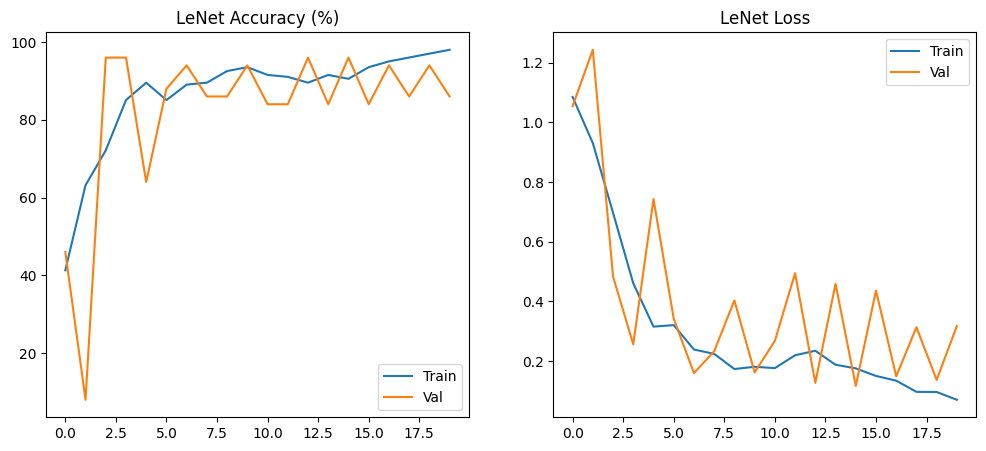

In [ ]:
plt.figure(figsize=(12,5))

# Accuracy Graph
plt.subplot(1,2,1)
plt.plot([x*100 for x in history_lenet.history['accuracy']], label='Train')
plt.plot([x*100 for x in history_lenet.history['val_accuracy']], label='Val')
plt.title("LeNet Accuracy (%)")
plt.legend()

# Loss Graph
plt.subplot(1,2,2)
plt.plot(history_lenet.history['loss'], label='Train')
plt.plot(history_lenet.history['val_loss'], label='Val')
plt.title("LeNet Loss")
plt.legend()

plt.show()

In [ ]:
test_loss_l, test_acc_l = model_lenet.evaluate(test_ds)

print("LeNet Test Accuracy: {:.2f}%".format(test_acc_l * 100))

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 148ms/step - accuracy: 0.8656 - loss: 0.3651
LeNet Test Accuracy: 84.85%


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step


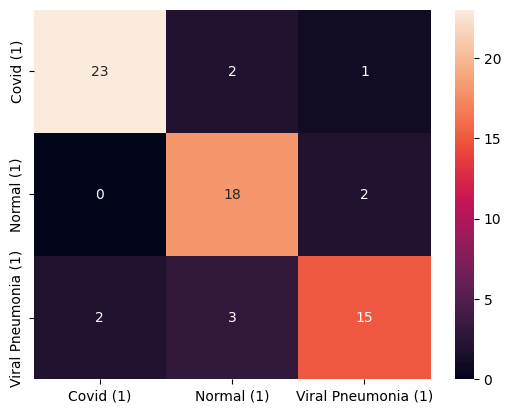

                     precision    recall  f1-score   support

          Covid (1)       0.92      0.88      0.90        26
         Normal (1)       0.78      0.90      0.84        20
Viral Pneumonia (1)       0.83      0.75      0.79        20

           accuracy                           0.85        66
          macro avg       0.85      0.84      0.84        66
       weighted avg       0.85      0.85      0.85        66



In [ ]:
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model_lenet.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

cm = confusion_matrix(y_true, y_pred)

sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_names,
            yticklabels=class_names)
plt.show()
print(classification_report(y_true, y_pred, target_names=class_names))

In [ ]:
print("Custom CNN Accuracy: {:.2f}%".format(test_acc * 100))
print("LeNet Accuracy: {:.2f}%".format(test_acc_l * 100))

Custom CNN Accuracy: 81.82%
LeNet Accuracy: 84.85%


In [ ]:
y_probs = []

for images, labels in test_ds:
    preds = model.predict(images)
    y_probs.extend(preds)

y_probs = np.array(y_probs)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 585ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 282ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step


In [ ]:
from sklearn.preprocessing import label_binarize

y_true_bin = label_binarize(y_true, classes=[0,1,2])

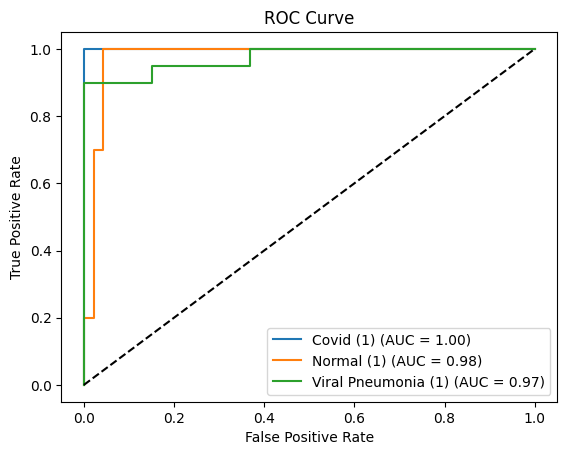

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure()

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{class_names[i]} (AUC = {roc_auc:.2f})")

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.title("ROC Curve")
plt.show()

#ROC curve plots True Positive Rate against False Positive Rate.
#AUC measures the model’s ability to distinguish between classes.
#An AUC close to 1 indicates excellent classification performance.